# Time-Dependent Facility Location for EV Charging Station Placement

**Graph Theory Research Project**

This notebook:
1. Downloads a real road network for a city (via OSMnx)
2. Builds a **static** p-median model (classic facility location, fixed travel times)
3. Builds a **time-dependent** p-median model (travel times scaled by simulated peak-hour congestion)
4. Compares the two solutions and quantifies how much worse the static-optimal placement performs under real peak-hour congestion
5. Visualizes both placements on an interactive map

**Setup (run once, e.g. in the first Colab cell):**
```
!pip install osmnx networkx matplotlib folium pulp numpy pandas
```

## 1. Imports

In [ ]:
!pip install osmnx networkx matplotlib folium pulp numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.5 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import networkx as nx
import osmnx as ox
import folium
import pulp
import matplotlib.pyplot as plt

## 2. Configuration

Change these values to fit your project (city, number of stations, sample sizes).

In [ ]:
CITY_NAME = "Western Province, Sri Lanka"  # change to your city/region of choice
NUM_STATIONS = 5                    # number of EV charging stations to place (p)
NUM_CANDIDATE_NODES = 40            # candidate sites sampled from the network (keep small for ILP speed)
NUM_DEMAND_NODES = 60               # demand points sampled from the network
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 3. Download Real Road Network

This pulls the actual street network for your chosen city from OpenStreetMap. Requires internet access.

In [ ]:
def get_road_network(city_name):
    print(f"Downloading road network for: {city_name} ...")
    G = ox.graph_from_place(city_name, network_type="drive")
    G = ox.add_edge_speeds(G)        # estimates speed (km/h) per edge from highway type
    G = ox.add_edge_travel_times(G)  # adds 'travel_time' (seconds) to each edge

    # IMPORTANT: keep only the largest strongly connected component.
    # OSM drive networks are directed (one-way streets), so without this,
    # randomly sampled demand/candidate nodes can end up unreachable from
    # each other, which silently corrupts the shortest-path matrices below
    # with huge "unreachable" penalty values.
    largest_cc_nodes = max(nx.strongly_connected_components(G), key=len)
    G = G.subgraph(largest_cc_nodes).copy()

    print(f"Network loaded (largest strongly connected component): {len(G.nodes)} nodes, {len(G.edges)} edges")
    return G

G = get_road_network(CITY_NAME)

Network loaded (largest strongly connected component): 125113 nodes, 283878 edges


## 4. Sample Demand Points and Candidate Station Sites

In [ ]:
def sample_nodes(G, n, seed_offset=0):
    random.seed(RANDOM_SEED + seed_offset)
    nodes = list(G.nodes)
    return random.sample(nodes, min(n, len(nodes)))

demand_nodes = sample_nodes(G, NUM_DEMAND_NODES, seed_offset=1)
candidate_nodes = sample_nodes(G, NUM_CANDIDATE_NODES, seed_offset=2)

print(f"Demand points: {len(demand_nodes)}")
print(f"Candidate sites: {len(candidate_nodes)}")

Demand points: 60
Candidate sites: 40


## 5. Build Static and Time-Dependent Travel Time Matrices

`t_ij` = shortest-path travel time from demand point i to candidate site j. The time-dependent version scales edge weights by a congestion multiplier before computing shortest paths.

In [ ]:
def build_travel_time_matrix(G, demand_nodes, candidate_nodes, congestion_multiplier=None):
    if congestion_multiplier is not None:
        G_temp = G.copy()
        for u, v, k, data in G_temp.edges(keys=True, data=True):
            base_time = data.get("travel_time", 1.0)
            if isinstance(congestion_multiplier, dict):
                mult = congestion_multiplier.get((u, v), 1.0)
            else:
                mult = congestion_multiplier
            data["weight"] = base_time * mult
        weight_key = "weight"
        graph_to_use = G_temp
    else:
        weight_key = "travel_time"
        graph_to_use = G

    matrix = np.zeros((len(demand_nodes), len(candidate_nodes)))
    for i, d in enumerate(demand_nodes):
        lengths = nx.single_source_dijkstra_path_length(graph_to_use, d, weight=weight_key)
        for j, c in enumerate(candidate_nodes):
            matrix[i, j] = lengths.get(c, 1e9)  # large penalty if unreachable
    return matrix

## 6. Simulate Peak-Hour Congestion Multipliers

Major roads (primary/trunk) get heavier rush-hour multipliers than residential streets. Replace this with real traffic data if available for your city.

In [ ]:
def simulate_peak_hour_multipliers(G, peak_multiplier_range=(1.5, 3.0)):
    multipliers = {}
    for u, v, k, data in G.edges(keys=True, data=True):
        highway = data.get("highway", "")
        if isinstance(highway, list):
            highway = highway[0]
        if highway in ("primary", "trunk", "primary_link", "trunk_link"):
            mult = random.uniform(*peak_multiplier_range)
        elif highway in ("secondary", "secondary_link"):
            mult = random.uniform(1.2, 2.0)
        else:
            mult = random.uniform(1.0, 1.3)
        multipliers[(u, v)] = mult
    return multipliers

print("Building STATIC (free-flow) travel time matrix...")
static_matrix = build_travel_time_matrix(G, demand_nodes, candidate_nodes)

print("Simulating peak-hour congestion multipliers...")
peak_multipliers = simulate_peak_hour_multipliers(G)

print("Building TIME-DEPENDENT (peak-hour) travel time matrix...")
peak_matrix = build_travel_time_matrix(G, demand_nodes, candidate_nodes, congestion_multiplier=peak_multipliers)

# Sanity check: how many demand-candidate pairs are unreachable (hit the 1e9 penalty)?
# If this is not 0, something is still wrong with connectivity.
unreachable_static = (static_matrix >= 1e9).sum()
unreachable_peak = (peak_matrix >= 1e9).sum()
print(f"Unreachable pairs -- static: {unreachable_static}, peak: {unreachable_peak} (out of {static_matrix.size} total pairs)")

Building STATIC (free-flow) travel time matrix...
Simulating peak-hour congestion multipliers...
Building TIME-DEPENDENT (peak-hour) travel time matrix...
Unreachable pairs -- static: 0, peak: 0 (out of 2400 total pairs)


## 7. p-Median Model (ILP)

Classic facility-location formulation: choose p candidate sites minimizing total demand-weighted travel cost to the nearest chosen site.

In [ ]:
def solve_p_median(cost_matrix, p):
    num_demand, num_candidates = cost_matrix.shape
    prob = pulp.LpProblem("p_median", pulp.LpMinimize)

    x = pulp.LpVariable.dicts("x", range(num_candidates), cat="Binary")
    y = pulp.LpVariable.dicts("y", (range(num_demand), range(num_candidates)), cat="Binary")

    prob += pulp.lpSum(
        cost_matrix[i, j] * y[i][j]
        for i in range(num_demand)
        for j in range(num_candidates)
    )

    for i in range(num_demand):
        prob += pulp.lpSum(y[i][j] for j in range(num_candidates)) == 1

    for i in range(num_demand):
        for j in range(num_candidates):
            prob += y[i][j] <= x[j]

    prob += pulp.lpSum(x[j] for j in range(num_candidates)) == p

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    chosen = [j for j in range(num_candidates) if pulp.value(x[j]) > 0.5]
    total_cost = pulp.value(prob.objective)
    return chosen, total_cost

## 8. Solve Both Models

In [ ]:
print(f"Solving static p-median (p={NUM_STATIONS})...")
static_chosen, static_cost = solve_p_median(static_matrix, NUM_STATIONS)
print(f"Static-optimal stations (candidate indices): {static_chosen}")
print(f"Static objective (free-flow total cost): {static_cost:.1f} sec")

print(f"\nSolving time-dependent p-median (p={NUM_STATIONS})...")
dynamic_chosen, dynamic_cost = solve_p_median(peak_matrix, NUM_STATIONS)
print(f"Time-dependent-optimal stations (candidate indices): {dynamic_chosen}")
print(f"Time-dependent objective (peak-hour total cost): {dynamic_cost:.1f} sec")

Solving static p-median (p=5)...
Static-optimal stations (candidate indices): [2, 10, 24, 30, 33]
Static objective (free-flow total cost): 50467.7 sec

Solving time-dependent p-median (p=5)...
Time-dependent-optimal stations (candidate indices): [2, 10, 21, 33, 38]
Time-dependent objective (peak-hour total cost): 83424.1 sec


## 9. Key Comparison

The core research question: how much worse does the static-optimal placement perform once real peak-hour congestion is applied?

In [ ]:
def evaluate_placement(chosen_indices, cost_matrix):
    sub_matrix = cost_matrix[:, chosen_indices]
    return sub_matrix.min(axis=1).sum()

static_placement_under_peak = evaluate_placement(static_chosen, peak_matrix)
dynamic_placement_under_peak = evaluate_placement(dynamic_chosen, peak_matrix)

gap_seconds = static_placement_under_peak - dynamic_placement_under_peak
gap_percent = 100 * gap_seconds / dynamic_placement_under_peak

print("=" * 60)
print("KEY RESULT")
print("=" * 60)
print(f"Static-optimal placement, evaluated under peak-hour congestion: {static_placement_under_peak:.1f} sec total")
print(f"Time-dependent-optimal placement, under peak-hour congestion:   {dynamic_placement_under_peak:.1f} sec total")
print(f"=> Using the static model costs an extra {gap_seconds:.1f} sec ({gap_percent:.1f}%) in total driver travel time during peak hours.")

KEY RESULT
Static-optimal placement, evaluated under peak-hour congestion: 84848.6 sec total
Time-dependent-optimal placement, under peak-hour congestion:   83424.1 sec total
=> Using the static model costs an extra 1424.4 sec (1.7%) in total driver travel time during peak hours.


## 10. Comparison Chart

A simple bar chart for your Findings/Results section.

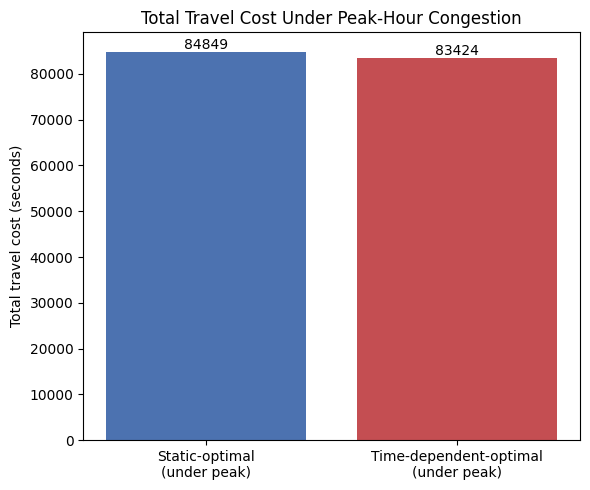

In [ ]:
labels = ["Static-optimal\n(under peak)", "Time-dependent-optimal\n(under peak)"]
values = [static_placement_under_peak, dynamic_placement_under_peak]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=["#4C72B0", "#C44E52"])
plt.ylabel("Total travel cost (seconds)")
plt.title("Total Travel Cost Under Peak-Hour Congestion")
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=150)
plt.show()

## 11. Visualize Placements on Map

Blue = static-optimal stations. Red = time-dependent-optimal stations. Gray dots = demand points.

## 11b. Get Human-Readable Locations for Chosen Stations

Converts the chosen candidate node indices into actual coordinates and nearest street/place names, so you can list real recommended locations in your Findings section.

In [ ]:
import time
import requests

def describe_stations(G, candidate_nodes, chosen_indices, label):
    print(f"\n--- {label} ---")
    results = []
    for idx in chosen_indices:
        node = candidate_nodes[idx]
        lat = G.nodes[node]["y"]
        lon = G.nodes[node]["x"]
        try:
            resp = requests.get(
                "https://nominatim.openstreetmap.org/reverse",
                params={"lat": lat, "lon": lon, "format": "json"},
                headers={"User-Agent": "graph-theory-student-project"},
                timeout=10,
            )
            place_name = resp.json().get("display_name", "Unknown location")
        except Exception as e:
            place_name = f"(reverse geocoding failed: {e})"
        time.sleep(1)  # Nominatim usage policy: max 1 request/sec

        print(f"Node {node} -> ({lat:.5f}, {lon:.5f}) -> {place_name}")
        results.append({"node": node, "lat": lat, "lon": lon, "address": place_name})
    return results

static_locations = describe_stations(G, candidate_nodes, static_chosen, "STATIC-OPTIMAL STATIONS")
dynamic_locations = describe_stations(G, candidate_nodes, dynamic_chosen, "TIME-DEPENDENT-OPTIMAL STATIONS")


--- STATIC-OPTIMAL STATIONS ---
Node 4723956293 -> (6.70655, 79.99614) -> Atulugama Road, Bandaragama, Bandaragama DS Division, Kalutara District, Western Province, 12530, Sri Lanka
Node 6335936269 -> (6.50628, 80.10082) -> Matugama, Matugama DS Division, Kalutara District, Western Province, 12100, Sri Lanka
Node 5285425832 -> (6.92638, 79.98262) -> Kaduwela, Colombo District, Western Province, 10640, Sri Lanka
Node 637369471 -> (6.84578, 79.89069) -> Vihara Mawatha, Pepiliyana, Bellanthara, Bellanvila, Colombo District, Western Province, 10350, Sri Lanka
Node 4177532052 -> (7.10153, 79.89270) -> Mathree Mawatha, Ekala, Gampaha District, Western Province, 11380, Sri Lanka

--- TIME-DEPENDENT-OPTIMAL STATIONS ---
Node 4723956293 -> (6.70655, 79.99614) -> Atulugama Road, Bandaragama, Bandaragama DS Division, Kalutara District, Western Province, 12530, Sri Lanka
Node 6335936269 -> (6.50628, 80.10082) -> Matugama, Matugama DS Division, Kalutara District, Western Province, 12100, Sri Lanka

In [ ]:
def visualize_placements(G, demand_nodes, candidate_nodes, static_chosen, dynamic_chosen,
                          static_locations=None, dynamic_locations=None, out_html="placement_map.html"):
    center_node = demand_nodes[0]
    center_lat = G.nodes[center_node]["y"]
    center_lon = G.nodes[center_node]["x"]

    # cartodbpositron now requires an API key, and the default OSM tiles
    # block Colab traffic. Esri's World Street Map tiles work without a key.
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
        attr="Esri, DeLorme, NAVTEQ",
        name="Esri World Street Map",
    ).add_to(m)

    for d in demand_nodes:
        folium.CircleMarker(
            location=[G.nodes[d]["y"], G.nodes[d]["x"]],
            radius=2, color="gray", fill=True, fill_opacity=0.5
        ).add_to(m)

    for pos, idx in enumerate(static_chosen):
        node = candidate_nodes[idx]
        popup_text = "Static-optimal station"
        if static_locations is not None:
            popup_text = f"Static-optimal station<br>{static_locations[pos]['address']}"
        folium.Marker(
            location=[G.nodes[node]["y"], G.nodes[node]["x"]],
            popup=folium.Popup(popup_text, max_width=300),
            icon=folium.Icon(color="blue", icon="bolt", prefix="fa"),
        ).add_to(m)

    for pos, idx in enumerate(dynamic_chosen):
        node = candidate_nodes[idx]
        popup_text = "Time-dependent-optimal station"
        if dynamic_locations is not None:
            popup_text = f"Time-dependent-optimal station<br>{dynamic_locations[pos]['address']}"
        folium.Marker(
            location=[G.nodes[node]["y"], G.nodes[node]["x"]],
            popup=folium.Popup(popup_text, max_width=300),
            icon=folium.Icon(color="red", icon="bolt", prefix="fa"),
        ).add_to(m)

    m.save(out_html)
    print(f"Map saved to {out_html}")
    return m

result_map = visualize_placements(
    G, demand_nodes, candidate_nodes, static_chosen, dynamic_chosen,
    static_locations=static_locations, dynamic_locations=dynamic_locations,
)
result_map

Map saved to placement_map.html


## 12. Notes for Your Report

- **Section 4.6 Limitation:** Congestion multipliers here are simulated by road classification, not derived from empirical traffic sensors, due to data availability. State this explicitly.
- **Section 4.6 Limitation:** Station capacity/queueing is not modeled — this is a location-only model, not an operations model.
- Use the printed KEY RESULT percentage as your headline Findings number.
- Use `comparison_chart.png` and a screenshot of the map as your report figures.
- Re-run with a different `CITY_NAME` or `RANDOM_SEED` to sanity-check that the result direction (time-dependent model outperforms static under peak conditions) is consistent, not a one-off artifact of the random seed.